# Практика 18. Множинна лінійна регресія: відбір предикторів, інтерпретація коефіцієнтів, діагностика залишків

**Варіант 1: Київ**

Мета: побудувати й порівняти моделі множинної лінійної регресії, інтерпретувати коефіцієнти «за інших рівних умов», перевірити VIF і діагностувати залишки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

np.random.seed(42)
variant = 1
city = 'Київ'
mean_temp = 9.5
amplitude = 14.0
hum_base = 74.0
alpha = 0.05

rows = []
for month in range(1, 13):
    temp = mean_temp + amplitude * np.cos((month - 7) / 12 * 2 * np.pi) + np.random.normal(0, 1.0)
    humidity = hum_base + np.random.normal(0, 5.0)
    if temp < 8:
        opal_days = 30
    elif temp < 12:
        opal_days = 15
    else:
        opal_days = 0
    cost = 200 - 9.0 * temp + 0.6 * humidity + 2.5 * opal_days + np.random.normal(0, 15)
    rows.append({
        'місто': city,
        'місяць': month,
        'температура': round(temp, 1),
        'вологість': round(humidity, 1),
        'опалювальні_дні': opal_days,
        'витрати_на_опалення': round(cost, 1),
    })

heating = pd.DataFrame(rows)
print(f'Варіант {variant}: {city}')
print(heating)

Варіант 1: Київ
   місто  місяць  температура  вологість  опалювальні_дні  витрати_на_опалення
0   Київ       1         -4.0       73.3               30                364.7
1   Київ       2         -1.1       72.8               30                325.1
2   Київ       3          4.1       77.8               30                277.9
3   Київ       4         10.0       71.7               15                183.1
4   Київ       5         16.7       64.4                0                 62.1
5   Київ       6         21.1       68.9                0                 56.5
6   Київ       7         22.6       66.9                0                 58.8
7   Київ       8         21.4       74.3                0                 30.6
8   Київ       9         16.0       74.6                0                 83.9
9   Київ      10          9.9       71.0               15                186.8
10  Київ      11          1.9       83.3               30                307.7
11  Київ      12         -3.7       

## Побудова набору `heating`

Варіант 1 — Київ: середньорічна температура `9.5 °C`, амплітуда `14 °C`, базова вологість `74%`. Дані містять 12 місяців.

In [2]:
X_two = sm.add_constant(heating[['температура', 'вологість']])
y = heating['витрати_на_опалення']
model_two = sm.OLS(y, X_two).fit()
print(f'R² = {model_two.rsquared:.4f}')
print(f'adjusted R² = {model_two.rsquared_adj:.4f}')

R² = 0.9756
adjusted R² = 0.9701


## Завдання 1. Модель із двома предикторами

Будуємо модель `витрати_на_опалення ~ температура + вологість` через `statsmodels.OLS()` із константою.

In [3]:
print(model_two.summary())
print('\nКоефіцієнти та p-value:')
print(pd.DataFrame({'coef': model_two.params, 'p-value': model_two.pvalues}).round(4))
for predictor in ['температура', 'вологість']:
    coefficient = model_two.params[predictor]
    print(f'{predictor}: за інших рівних умов зміна на 1 одиницю змінює витрати на {coefficient:.4f} умовних одиниць.')

                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.976
Model:                             OLS   Adj. R-squared:                  0.970
Method:                  Least Squares   F-statistic:                     179.6
Date:                 Mon, 21 Sep 2026   Prob (F-statistic):           5.58e-08
Time:                         15:40:15   Log-Likelihood:                -52.453
No. Observations:                   12   AIC:                             110.9
Df Residuals:                        9   BIC:                             112.4
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         223.1684    122.718      1

## Завдання 2. Інтерпретація коефіцієнтів

Кожен коефіцієнт моделі читаємо «за інших рівних умов»: коефіцієнт температури — при незмінній вологості, а коефіцієнт вологості — при незмінній температурі. Окремо дивимося на `P>|t|` для перевірки значущості при `α = 0.05`.

In [4]:
vif_two = pd.DataFrame({
    'предиктор': X_two.columns,
    'VIF': [variance_inflation_factor(X_two.values, i) for i in range(X_two.shape[1])],
})
print(vif_two.round(3))
print('Температура і вологість не мають проблемної мультиколінеарності.' if vif_two.loc[vif_two['предиктор'] != 'const', 'VIF'].max() <= 5 else 'Є предиктор із VIF > 5: коефіцієнти слід інтерпретувати обережно.')

     предиктор    VIF
0        const  1.000
1  температура  1.553
2    вологість  1.553
Температура і вологість не мають проблемної мультиколінеарності.


## Завдання 3. Перевірка мультиколінеарності через VIF

Практичний орієнтир: `VIF > 5` потребує уваги, а `VIF > 10` часто вважають серйозною проблемою. У моделі Завдання 1 оцінюємо VIF температури та вологості.

In [5]:
X_three = sm.add_constant(heating[['температура', 'вологість', 'опалювальні_дні']])
model_three = sm.OLS(y, X_three).fit()
vif_three = pd.DataFrame({
    'предиктор': X_three.columns,
    'VIF': [variance_inflation_factor(X_three.values, i) for i in range(X_three.shape[1])],
})

print(f'Модель 2 предиктори: R² = {model_two.rsquared:.4f}, adjusted R² = {model_two.rsquared_adj:.4f}')
print(f'Модель 3 предиктори: R² = {model_three.rsquared:.4f}, adjusted R² = {model_three.rsquared_adj:.4f}')
print('VIF розширеної моделі:')
print(vif_three.round(3))
print('Третій предиктор виправдав штраф adjusted R².' if model_three.rsquared_adj > model_two.rsquared_adj else 'Третій предиктор не виправдав штраф adjusted R².')

Модель 2 предиктори: R² = 0.9756, adjusted R² = 0.9701
Модель 3 предиктори: R² = 0.9916, adjusted R² = 0.9884
VIF розширеної моделі:
         предиктор     VIF
0            const   1.000
1      температура  13.410
2        вологість   1.899
3  опалювальні_дні  15.618
Третій предиктор виправдав штраф adjusted R².


## Завдання 4. Третій предиктор: R² проти adjusted R²

Додаємо `опалювальні_дні` до моделі. Оскільки цей предиктор побудований із температури, перевіряємо також VIF розширеної моделі.

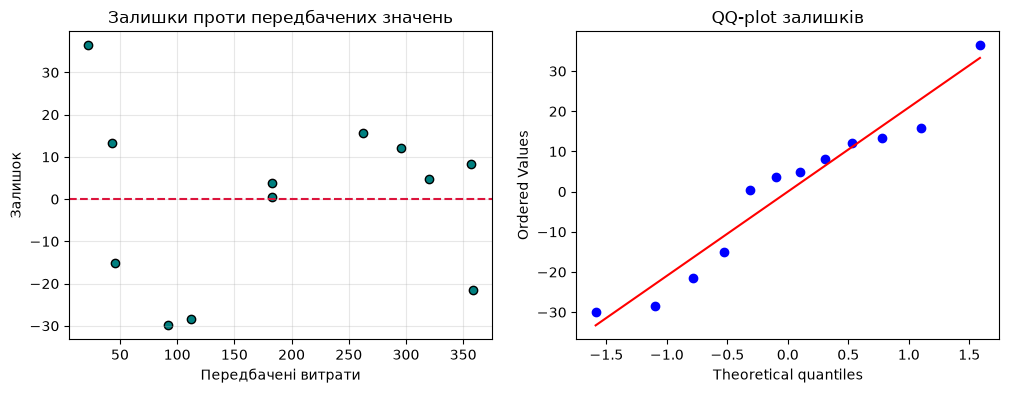

Кореляція залишків і fitted: 0.000000
Shapiro-Wilk: statistic = 0.9388, p-value = 0.482848
H₀ про нормальність не відхиляємо.


In [6]:
from scipy import stats

fitted = model_two.fittedvalues
residuals = model_two.resid
shapiro_stat, shapiro_p = stats.shapiro(residuals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(fitted, residuals, color='teal', edgecolor='black')
ax1.axhline(0, color='crimson', linestyle='--')
ax1.set_xlabel('Передбачені витрати')
ax1.set_ylabel('Залишок')
ax1.set_title('Залишки проти передбачених значень')
ax1.grid(alpha=0.3)

stats.probplot(residuals, dist='norm', plot=ax2)
ax2.set_title('QQ-plot залишків')
plt.show()

print(f'Кореляція залишків і fitted: {np.corrcoef(residuals, fitted)[0, 1]:.6f}')
print(f'Shapiro-Wilk: statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.6f}')
print('H₀ про нормальність не відхиляємо.' if shapiro_p >= alpha else 'H₀ про нормальність відхиляємо.')

## Завдання 5. Діагностика залишків

Для двопредикторної моделі перевіряємо залишки проти передбачених значень, QQ-plot і критерій Шапіро-Вілка при `α = 0.05`.

In [7]:
simple_X = sm.add_constant(heating[['температура']])
simple_model = sm.OLS(y, simple_X).fit()
comparison = pd.DataFrame({
    'модель': ['проста: температура', 'множинна: температура + вологість'],
    'R²': [simple_model.rsquared, model_two.rsquared],
    'adjusted R²': [simple_model.rsquared_adj, model_two.rsquared_adj],
})
print(comparison.round(4))
print(f'Приріст R² після додавання вологості: {model_two.rsquared - simple_model.rsquared:.4f}')

                              модель      R²  adjusted R²
0                проста: температура  0.9742       0.9716
1  множинна: температура + вологість  0.9756       0.9701
Приріст R² після додавання вологості: 0.0014


## Завдання 6. Порівняння з простою регресією

Порівнюємо просту модель із температурою з двопредикторною моделлю. Додавання вологості може збільшити звичайний R², але adjusted R² покаже, чи приріст виправдовує ускладнення.

## Контрольні питання

**1. Навіщо `sm.add_constant()`?** Він додає стовпець одиниць для оцінювання вільного члена. Без нього модель проходила б через нуль, а перетин і всі інтерпретації могли б бути викривлені.

**2. Множинний і простий коефіцієнт.** У множинній регресії коефіцієнт показує зміну Y при зміні одного X за незмінних інших предикторів. У простій моделі інші фактори не контролюються.

**3. Чому R² не зменшується?** Додавання предиктора не звужує простір моделей, тому МНК може залишити його коефіцієнт біля нуля й не погіршити підгонку. Adjusted R² додає штраф за зайвий предиктор.

**4. Що означає VIF?** VIF ≈ 1 означає майже відсутню лінійну залежність предиктора від інших. VIF > 10 вказує на серйозну мультиколінеарність; варто переглянути предиктори, об'єднати їх або вилучити надлишковий.

## Підсумок

- Побудовано дві моделі `statsmodels.OLS`: з двома та трьома предикторами.
- Коефіцієнти інтерпретовано за інших рівних умов.
- Мультиколінеарність перевірено через VIF.
- Порівняно R² і adjusted R² та проведено діагностику залишків.
- Результати зіставлено з простою регресією температури з Практики 17.